In [1]:
import os
import sys

import cv2 as cv
import matplotlib.pyplot as plt

import config as cfg

TARGET = 'daylight-2016-01-06T00_00_00Z'

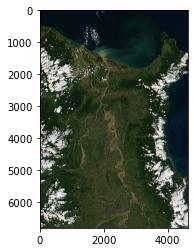

In [9]:
img_path = r'C:\Users\paolo\OneDrive\Desktop\Projects\laguna-philippines-mapping-fisheries\src\data\Satellite Images\Satellite Images\Day Time\daylight-30m-per-pixel\2016\daylight-2016-01-06T00_00_00Z.tiff'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [10]:
from osgeo import gdal
ds = gdal.Open(img_path)

width = ds.RasterXSize
height = ds.RasterYSize
gt = ds.GetGeoTransform()

minx = gt[0]
miny = gt[3] + width*gt[4] + height*gt[5] 
maxx = gt[0] + width*gt[1] + height*gt[2]
maxy = gt[3] 

print(minx, miny, maxx, maxy)

121.07971951111764 16.904500000000002 122.34898048888235 18.769800000000004


In [11]:
img.shape

(6791, 4621, 3)

In [29]:
unitpxy = (maxy-miny) / img.shape[0]

In [30]:
unitpxx = (maxx-minx) / img.shape[1]

In [38]:
unitpxy, unitpxx

(0.0002746723604771022, 0.000274672360477105)

In [40]:
grid_coords = dict(
    x=[],
    y=[],
)
starting_x = minx 
starting_y = miny

grid_coords['x'].append(starting_x)
grid_coords['y'].append(starting_y)

grid = 1

while starting_x <= maxx or starting_y <= maxy:
    if starting_x >= maxx:
        starting_x = minx
        starting_y += unitpxy * 150
    
    starting_x += unitpxx * 92

    grid_coords['x'].append(starting_x)
    grid_coords['y'].append(starting_y)


len(grid_coords['x'])

2398

# Proximity

In [ ]:
# Estimated Province
